In [ ]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_venn import venn3, venn2

sys.path.append('../../scripts/coordinates_analysis')

from load import load_samples
from compare import compare_samples
from save import save_overlaps

# I. Compare peaks from different samples
This script analyzes overlaps between multiple BED files and categorizes them based on their overlap patterns across different samples.


Useful for comparing peaks from different experiments to identify common and unique regions.
Produce .bed files and venn diagrams.

#### Provide arguments - output directory and pathes to .bed files to compare

In [ ]:
output_dir = '../../results/compared_peaks'

#################### EXAMPLE USAGE ####################
################ PASTE YOUR PATHS INSTEAD #############

sample1_path = '../../../ChEC_Data_Complete/homer_peaks_merged/RDY466_as_DMSO_25_nC.bed'
sample2_path = '../../../ChEC_Data_Complete/homer_peaks_merged/RDY466_as_IAA_25_nC.bed'
#sample3_path = ''

include_neighbours = 0

#### Run comparison

In [ ]:
# For two samples
samples = load_samples(sample1_path, sample2_path)

# For three samples
#samples = load_samples(sample1_path, sample2_path, sample3_path)

overlaps_df = compare_samples(samples, include_neighbours=include_neighbours)

#### Save compared peaks to output_directory

In [85]:
# save_overlaps() saves .bed files and returns subdirectory where files are saved
output_subdir = save_overlaps(overlaps_df, output_dir)

"""
Description of output .bed files

output_dir/
└── sample1_sample2
   ├── in_sample1_ex_sample2.bed -  unique peaks for sample1, excluding common peaks with sample2
   ├── in_sample2_ex_sample1.bed -  unique peaks for sample2, excluding common peaks with sample1
   └── in_sample1_sample2_ex.bed -  common peaks for both sample1 and sample2. 
                                    Common peaks are merged by centers.
"""

'\nDescription of output .bed files\n\noutput_dir/\n└── sample1_sample2\n   ├── in_sample1_ex_sample2.bed -  unique peaks for sample1, excluding common peaks with sample2\n   ├── in_sample2_ex_sample1.bed -  unique peaks for sample2, excluding common peaks with sample1\n   └── in_sample1_sample2_ex.bed -  common peaks for both sample1 and sample2. \n                                    Common peaks are merged by centers.\n'

#### Plot venn diagram (for 2 or 3 samples)

In [86]:
def plot_venn_diagram(overlaps_df, output_subdir):
    '''Plot venn diagram for 2 or 3 samples
    '''
    df_binary =  overlaps_df.iloc[:, 4:]
    sets = [set(np.argwhere(v).ravel()) for _,v in df_binary.items()]
    labels = [l.replace('.bed','') for l in df_binary.columns] # labels are files names, however you can change it
    # labels= [] # venn without labels
    if len(sets) == 2:
        venn2(sets, labels, set_colors=("green","red")) # HERE CHANGE COLORS 
    elif len(sets) == 3:
        venn3(sets, labels) # HERE CHANGE COLORS 
    else:
        print(f"Warning: Venn diagram for {len(sets)} sets not supported. Using first 3 columns.")
        venn3(sets[:3], set_labels=labels[:3])
    
    plt.savefig(os.path.join(output_subdir, "venn_diagram.png"), dpi=300, bbox_inches='tight')

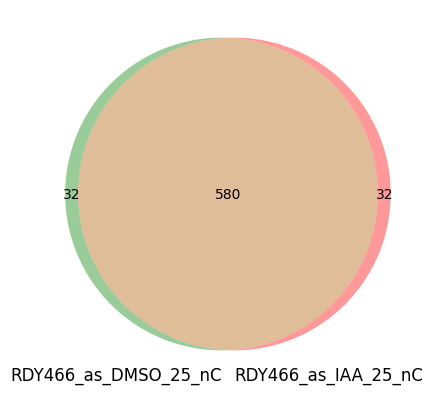

In [87]:
plot_venn_diagram(overlaps_df, output_subdir)